In [1]:
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-03-17 14:21:24.243798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773757284.267952    2583 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773757284.275203    2583 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773757284.294256    2583 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773757284.294279    2583 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773757284.294282    2583 computation_placer.cc:177] computation placer alr

In [2]:
data=tf.keras.datasets.mnist

In [3]:
(X_train,y_train),(X_test,y_test)=data.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
model=tf.keras.models.Sequential()

# CNN
model.add(tf.keras.layers.Conv2D(32,padding='valid',activation='relu',kernel_size=(3,3),input_shape=(28,28,1)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(tf.keras.layers.Conv2D(32,padding='valid',activation='relu',kernel_size=(3,3)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(tf.keras.layers.Flatten())
# ANN

model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dense(10,activation='softmax'))

I0000 00:00:1773757295.366787    2583 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773757295.371974    2583 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,826 (89.16 KB)

 Trainable params: 22,826 (89.16 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
@tf.function
def train_step(X, y):
    with tf.GradientTape() as tape:
        pred = model(X, training=True)
        loss = loss_fn(y, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [8]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(X_train.shape[0]).batch(batch_size).prefetch(tf.data.AUTOTUNE) 

epochs = 40
loss_val=[]
for i in range(epochs):
    for X_batch, y_batch in dataset:
        loss = train_step(X_batch, y_batch)
    loss_val.append(loss)
    print("Epoch:", i+1, "Loss:", loss.numpy())

I0000 00:00:1773757297.586240    2644 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch: 1 Loss: 0.8984065
Epoch: 2 Loss: 0.24487752
Epoch: 3 Loss: 0.26101243
Epoch: 4 Loss: 0.031686973
Epoch: 5 Loss: 0.07298247
Epoch: 6 Loss: 0.034580734
Epoch: 7 Loss: 0.007205241
Epoch: 8 Loss: 0.01785629
Epoch: 9 Loss: 0.027822798
Epoch: 10 Loss: 0.008831135
Epoch: 11 Loss: 0.16031641
Epoch: 12 Loss: 0.006727481
Epoch: 13 Loss: 0.009718903
Epoch: 14 Loss: 0.055207897
Epoch: 15 Loss: 0.010771003
Epoch: 16 Loss: 0.13907792
Epoch: 17 Loss: 0.060479205
Epoch: 18 Loss: 0.0032669976
Epoch: 19 Loss: 0.054823685
Epoch: 20 Loss: 0.0010786636
Epoch: 21 Loss: 0.018457713
Epoch: 22 Loss: 0.0068627563
Epoch: 23 Loss: 0.04440479
Epoch: 24 Loss: 0.06387192
Epoch: 25 Loss: 0.0072423206
Epoch: 26 Loss: 0.005387965
Epoch: 27 Loss: 0.0020583377
Epoch: 28 Loss: 0.0039561647
Epoch: 29 Loss: 0.0003493279
Epoch: 30 Loss: 0.03282923
Epoch: 31 Loss: 0.0013973358
Epoch: 32 Loss: 0.00292607
Epoch: 33 Loss: 0.0011299759
Epoch: 34 Loss: 0.0011036798
Epoch: 35 Loss: 0.00073823956
Epoch: 36 Loss: 0.03709902
Ep

In [9]:
accuracy=np.mean(np.argmax(model.predict(X_train),axis=1)==y_train)
print("Training Accuracy:", accuracy*100)
accuracy=np.mean(np.argmax(model.predict(X_test),axis=1)==y_test)
print("Testing Accuracy:", accuracy*100)

I0000 00:00:1773757363.456011    2642 service.cc:152] XLA service 0x7e17dc016890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773757363.456050    2642 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773757363.456057    2642 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 115/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

I0000 00:00:1773757363.857076    2642 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Training Accuracy: 99.83833333333332
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing Accuracy: 98.88


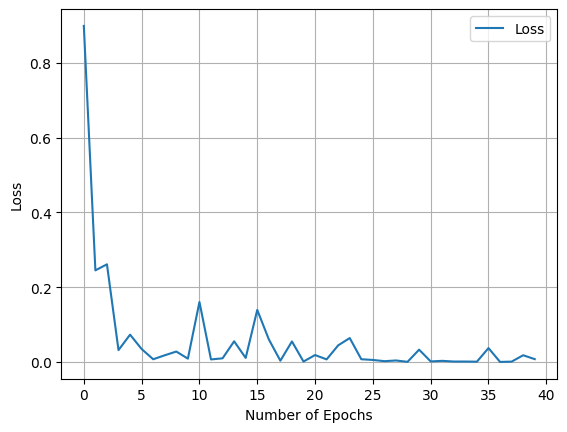

In [10]:
import matplotlib.pyplot as plt
plt.plot(loss_val,label='Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()